# $\chi_t$ and $\chi_t'$ by quadrature, for any noise density (new Section 3.4)

The noise enters the four filters of Section 3 only through $\chi_t(e_t)$ and $\chi_t'(e_t)$. The Gaussian and the Laplacian have them in closed form; for the generalized Gaussian with $\beta^* = 0.2$ and for Student's $t$ they come from a one-dimensional quadrature over the scalar posterior (21). This notebook writes that quadrature, checks it, and puts it in the sKF.

## Equations

**sKF, eqs. (16), (35), (36)**
$$e_t = d_t - x_t^\mathsf{T}w_{t-1} \qquad \tilde v_t = v_{t-1} + \varepsilon \qquad \sigma_t^2 = \tilde v_t\|x_t\|^2$$
$$w_t = w_{t-1} + \frac{x_t}{\|x_t\|^2}\,\chi_t \qquad v_t = \tilde v_t\left(1 - \frac{\chi_t'}{M}\right)$$

**The correction, eqs. (21), (30)**
$$p(s\,|\,y_{1:t}) = \frac{\mathcal N(s;0,\sigma_t^2)\,p_\eta(e_t - s)}{\int \mathcal N(s;0,\sigma_t^2)\,p_\eta(e_t - s)\,ds}$$
$$\chi_t = \int s\,p(s\,|\,y_{1:t})\,ds \qquad \chi_t' = 1 - \frac{1}{\sigma_t^2}\int (s - \chi_t)^2\,p(s\,|\,y_{1:t})\,ds$$

**The noise the filter assumes**

| assumed noise | $p_\eta(u) \propto$ | $\chi_t$ |
|---|---|---|
| Gaussian | $e^{-u^2/2v_\eta}$ | $\frac{\sigma_t^2}{\sigma_t^2 + v_\eta}\,e_t$, eq. (38) |
| Laplacian | $e^{-\lvert u\rvert/b_\eta}$ | $\tau_t\Lambda_t$, eq. (43) |
| generalized Gaussian | $e^{-(\lvert u\rvert/\alpha)^\beta}$ | quadrature |
| Student-t | $\left(1 + (u/c)^2/\nu\right)^{-(\nu+1)/2}$ | quadrature |

$v_\eta = 0.258$, $b_\eta = \mathrm{E}|\eta_t| = 0.128$, $\beta^* = 0.2$, $\alpha_* = 8.4\cdot10^{-6}$, $\nu = 0.51$, $c = 8.9\cdot10^{-3}$

**Laplacian closed form, eqs. (39)–(43)**
$$u_t = \frac{e_t}{\sigma_t} \quad k_t = \frac{\sigma_t}{b_\eta} \quad \tau_t = \frac{\sigma_t^2}{b_\eta} \quad R_t^\pm = \mathcal R(k_t \pm u_t),\ \mathcal R(z) = \frac{\Phi(-z)}{\phi(z)} \quad \Lambda_t = \frac{R_t^- - R_t^+}{R_t^- + R_t^+}$$
$$\chi_t = \tau_t\Lambda_t \qquad \chi_t' = \frac{2k_t}{R_t^- + R_t^+} - k_t^2\left(1 - \Lambda_t^2\right)$$

**Quadrature (no closed form)**
$$\chi_t \approx \frac{\sum_i q_i\,s_i}{\sum_i q_i} \qquad \chi_t' \approx 1 - \frac{\sum_i q_i\,(s_i - \chi_t)^2}{\sigma_t^2\sum_i q_i} \qquad q_i = w_i\,\mathcal N(s_i;0,\sigma_t^2)\,p_\eta(e_t - s_i)$$
$s_i, w_i$: Gauss-Legendre nodes and weights, 100 per piece, on the three pieces between the sorted cuts
$-10\sigma_t,\ 0,\ e_t,\ 10\sigma_t$. For $\beta < 1$ the nodes go in $z = (|e_t - s|/\alpha)^\beta$,
and $q_i$ carries $ds/dz = (\alpha/\beta)\,z^{1/\beta - 1}$.

## 1. Imports

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lfilter
from scipy.special import gammaln, log_ndtr
from scipy.stats import gennorm
from scipy.stats import t as student_t
import rir_generator as rir

NOTEBOOK_START = time.time()                   # for the total printed at the very end
print("imports ready")

imports ready


## 2. The scenario

Notebook 07's, unchanged: $M = 128$ room impulse response, AR($-0.9$) input, generalized Gaussian noise with $\beta^* = 0.2$ at SNR $= 5$ dB, $b_\eta = \mathrm{E}|\eta_t|$.

In [2]:
# Copied from notebook 07, commit f26ed36.
M = 128                     # filter length / length of the impulse response
N = 96000                   # steps per run (12 s at 8 kHz, the span of Fig. 3a of the paper)
R = 20                      # independent realisations
WARMUP = 500                # AR samples discarded so the input starts stationary

# AR_A = 0.0 reproduces the white input of notebook 05; BETA = 1.0, with TARGET_DB = -15 in
# section 4, reproduces the Laplacian noise of notebook 06. The cache of section 4 keys on the
# b_eta convention alone, so change B_ETA_RULE or CACHE_PREFIX there as well when you change
# AR_A or BETA, or the sweep will load the results of another scenario.
AR_A = -0.9                 # AR(1) coefficient of the input
SNR_DB = 5.0                # nominal signal-to-noise ratio, as in Fig. 3 of the paper
BETA = 0.2                  # shape of the generalized Gaussian measurement noise
VAR_THETA_0 = 2.0           # initial prior variance on each weight, as in notebooks 01 and 02
FS = 8000                   # sampling rate [Hz], the rate of section 7.1 of the draft

# The room of section 7.1 of the draft, simulated with ref. [24] (image method).
ROOM = [5, 10, 6]           # room dimensions [m]
T60 = 0.2                   # reverberation time [s]
C_SOUND = 340               # speed of sound [m/s]
SRC = [1, 2.5, 2]           # source position [m]
MIC = [1, 1.5, 1]           # receiver position [m]

# Generated once and then fixed. Normalised to unit norm: misalignment is scale-invariant
# and SNR_DB is imposed below from P_signal, so the normalisation changes nothing except
# keeping the grid of section 4 on the scale notebook 03 tuned it at.
ho = rir.generate(c=C_SOUND, fs=FS, r=MIC, s=SRC, L=ROOM,
                  reverberation_time=T60, nsample=M).flatten()
ho = ho/np.linalg.norm(ho)

# Signal power, in closed form: r[k] = AR_A^|k| for a unit-variance AR(1) input.
lags = np.abs(np.subtract.outer(np.arange(M), np.arange(M)))
Rxx = AR_A**lags
P_signal = ho @ Rxx @ ho

var_eta = P_signal/10**(SNR_DB/10)                 # noise variance that gives SNR_DB

# Scale of the generalized Gaussian with variance var_eta:
# Var = scale^2 Gamma(3/beta)/Gamma(1/beta).
scale_gg = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))


def laplace_scale(var_eta):
    """b_eta = E|eta_t| of the generalized Gaussian of variance var_eta: the Laplacian closest to it
    in KL(p || q), the direction of eq. (10), and its maximum-likelihood fit."""
    scale = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))   # generalized Gaussian scale
    return scale*np.exp(gammaln(2/BETA) - gammaln(1/BETA))               # E|eta| = scale Gamma(2/b)/Gamma(1/b)


b_eta = laplace_scale(var_eta)                     # the scale the filters are told
b_eta_variance = np.sqrt(var_eta/2)                # the scale notebooks 03-06 told them

print(f"signal power = {P_signal:.4f}")
print(f"var_eta      = {var_eta:.4e}   (nominal, at {SNR_DB:.0f} dB SNR)")
print(f"noise scale  = {scale_gg:.4e}   (generalized Gaussian, beta = {BETA})")
print()
print(f"b_eta = E|eta|     = {b_eta:.4e}   (used by the filters)")
print(f"sqrt(var_eta/2)    = {b_eta_variance:.4e}   (old convention, notebooks 03-06): "
      f"{b_eta_variance/b_eta:.2f}x larger")

# At beta = 1 the noise is already a Laplace, and matching E|eta| and matching the variance
# give the same scale. Anywhere else the two conventions part ways.
if BETA == 1.0:
    assert np.isclose(b_eta, b_eta_variance), f"{b_eta} is not {b_eta_variance} at beta = 1"

signal power = 0.8173
var_eta      = 2.5844e-01   (nominal, at 5 dB SNR)
noise scale  = 8.4350e-06   (generalized Gaussian, beta = 0.2)

b_eta = E|eta|     = 1.2754e-01   (used by the filters)
sqrt(var_eta/2)    = 3.5947e-01   (old convention, notebooks 03-06): 2.82x larger


`generate_signals(seed)` returns one realisation: the input `x`, the observation `d` and the noise `eta`.

In [3]:
# Copied from notebook 07, commit f26ed36.
def generate_signals(seed):
    """One realisation: AR(1) input, its clean output through ho, and heavy-tailed noise."""
    rng = np.random.default_rng(seed)
    u = np.sqrt(1 - AR_A**2)*rng.standard_normal(N + WARMUP)   # driving noise, unit-variance x
    x = lfilter([1.0], [1.0, -AR_A], u)[WARMUP:]               # x_t = AR_A x_{t-1} + u_t
    y = np.convolve(ho, x)[:N]                                 # clean output, y_t = x_t' ho
    eta = gennorm.rvs(BETA, scale=scale_gg, size=N, random_state=rng)
    return x, y + eta, eta


x, d, eta = generate_signals(0)
print("x:", x.shape, " d:", d.shape)
print(f"noise, first realisation: std {eta.std():.4f}, "
      f"median |eta| {np.median(np.abs(eta)):.5f}, max |eta| {np.abs(eta).max():.4f}")

# Control on b_eta: the sampled mean |eta| of this realisation against the closed form above.
print(f"mean |eta|, sampled     : {np.abs(eta).mean():.4e}   "
      f"against b_eta = {b_eta:.4e}, the closed form")

x: (96000,)  d: (96000,)
noise, first realisation: std 0.4831, median |eta| 0.01889, max |eta| 24.7659
mean |eta|, sampled     : 1.2807e-01   against b_eta = 1.2754e-01, the closed form


## 3. The noise densities

Each is the KL / maximum-likelihood fit of its family to the simulated noise. Generalized Gaussian: $p_\eta(u) \propto e^{-(|u|/\alpha)^\beta}$, $\alpha(\beta) = \left(\beta\,\mathrm{E}|\eta_t|^\beta\right)^{1/\beta}$, $\mathrm{E}|\eta_t|^\beta = \alpha_*^\beta\,\Gamma\!\left(\tfrac{\beta+1}{\beta^*}\right)/\Gamma\!\left(\tfrac{1}{\beta^*}\right)$.
Student's $t$: $p_\eta(u) \propto \left(1 + (u/c)^2/\nu\right)^{-(\nu+1)/2}$, $\nu$ and $c$ by maximum likelihood on $10^6$ draws of the noise.

In [4]:
def gg_scale(beta, var_eta):
    """alpha(beta): the generalized Gaussian of shape beta closest in KL to the simulated noise."""
    alpha_true = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))                 # alpha_*
    mean_abs_pow = alpha_true**beta*np.exp(gammaln((beta + 1)/BETA) - gammaln(1/BETA))    # E|eta|^beta
    return (beta*mean_abs_pow)**(1/beta)                                                   # alpha(beta)


alpha_star = gg_scale(BETA, var_eta)               # the matched filter's scale: the true one
print(f"gg_scale(1, v)    = {gg_scale(1.0, var_eta):.6e}   laplace_scale(v) = {laplace_scale(var_eta):.6e}")
print(f"gg_scale(2, v)^2/2 = {gg_scale(2.0, var_eta)**2/2:.6e}   var_eta          = {var_eta:.6e}")
print(f"gg_scale(beta*, v) = {alpha_star:.6e}   alpha_* of the noise = {scale_gg:.6e}")

# Student-t: maximum likelihood over a large sample of the simulated noise, location fixed at 0.
start = time.time()
sample = gennorm.rvs(BETA, scale=scale_gg, size=1_000_000, random_state=np.random.default_rng(2026))
nu_t, location, scale_t = student_t.fit(sample, floc=0)
print(f"\nStudent-t fit over {len(sample)} draws: nu = {nu_t:.4f}, scale = {scale_t:.4e}   "
      f"[{time.time() - start:.0f} s]")
print(f"   the scale is {scale_t/b_eta:.3f} b_eta; nu < 1, so the fitted t has no mean")

gg_scale(1, v)    = 1.275368e-01   laplace_scale(v) = 1.275368e-01
gg_scale(2, v)^2/2 = 2.584427e-01   var_eta          = 2.584427e-01
gg_scale(beta*, v) = 8.434971e-06   alpha_* of the noise = 8.434971e-06



Student-t fit over 1000000 draws: nu = 0.5098, scale = 8.9181e-03   [12 s]
   the scale is 0.070 b_eta; nu < 1, so the fitted t has no mean


## 4. The quadrature

$$p(s\,|\,y_{1:t}) \propto \mathcal N(s; 0, \sigma_t^2)\,p_\eta(e_t - s) \qquad \chi_t = \mathrm{E}[s\,|\,y_{1:t}] \qquad \chi_t' = 1 - \frac{\mathrm{Var}[s\,|\,y_{1:t}]}{\sigma_t^2}$$

Gauss-Legendre on the pieces between the sorted cuts $-L\sigma_t$, $0$, $e_t$, $L\sigma_t$ ($L = 10$): the peaks of the prior and of the likelihood sit at the ends of pieces, where the nodes crowd.
For the generalized Gaussian with $\beta < 1$ the nodes go in $z = (|e_t - s|/\alpha)^\beta$, elsewhere in $s$; weights $q_i = w_i\,\frac{ds}{dz}\,\mathcal N(s_i; 0, \sigma_t^2)\,p_\eta(e_t - s_i)$, with
$$s = e_t \pm \alpha z^{1/\beta} \qquad \frac{ds}{dz} = \frac{\alpha}{\beta}z^{1/\beta - 1}$$

In [5]:
L_WINDOW = 10               # the prior N(s; 0, sigma^2) is below e^{-50} beyond L_WINDOW sigma


def log_likelihood(u, density, params):
    """log p_eta(u) up to a constant: the noise density the filter assumes, in eqs. (21) and (24)."""
    if density == "gg":                                # generalized Gaussian, shape beta, scale alpha
        return -(np.abs(u)/params["alpha"])**params["beta"]
    # Student-t, nu degrees of freedom and scale c: -(nu + 1)/2 log(1 + (u/c)^2/nu)
    return -0.5*(params["nu"] + 1)*np.log1p((u/params["scale"])**2/params["nu"])


def piece_in_s(e, s_a, s_b, density, params):
    """Gauss-Legendre nodes on [s_a, s_b], directly in s. Returns the nodes and the log of
    (weight x length x likelihood p_eta(e_t - s)), the prior left out."""
    length = s_b - s_a                                 # length of the piece
    s = s_a + length*params["nodes"]                   # nodes mapped from [0, 1] to [s_a, s_b]
    log_q = params["log_weights"] + np.log(length) + log_likelihood(e - s, density, params)
    return s, log_q


def piece_in_z(e, s_a, s_b, params):
    """Gauss-Legendre nodes on [s_a, s_b] in the variable z = (|e_t - s|/alpha)^beta, where the
    cusp of the likelihood at s = e_t becomes the smooth e^{-z}. Same output as piece_in_s."""
    alpha = params["alpha"]
    beta = params["beta"]
    side = 1.0 if s_a >= e else -1.0                   # the piece lies above or below e_t
    z_a = (abs(e - s_a)/alpha)**beta                   # z at the two ends of the piece
    z_b = (abs(e - s_b)/alpha)**beta
    z_low = min(z_a, z_b)
    length = max(z_a, z_b) - z_low                     # length of the piece in z
    z = z_low + length*params["nodes"]                 # nodes mapped from [0, 1] to the piece
    log_z = np.log(z)
    s = e + side*alpha*np.exp(log_z/beta)              # s = e_t + side alpha z^(1/beta)
    # log of weight x length x ds/dz x likelihood, with ds/dz = (alpha/beta) z^(1/beta - 1)
    # and the likelihood e^{-z}
    log_q = params["log_weights"] + np.log(length*alpha/beta) + (1/beta - 1)*log_z - z
    return s, log_q


def chi_quadrature(e, sigma, density, params):
    """chi_t(e_t) and chi'_t(e_t) of eq. (30), from the mean and variance of the scalar
    posterior (21), by Gauss-Legendre quadrature. Same output as chi_laplacian."""
    # Cuts at the peak of the prior (0), the peak of the likelihood (e_t) and the ends of the
    # prior (+-L sigma), so that both peaks sit at the ends of pieces, where the nodes crowd.
    cuts = sorted([-L_WINDOW*sigma, 0.0, e, L_WINDOW*sigma])
    s_all = []                                         # nodes in s of every piece
    log_q_all = []                                     # log of their weights, eq. (21) times ds
    for piece in range(3):
        s_a = cuts[piece]
        s_b = cuts[piece + 1]
        if s_b <= s_a:                                 # e_t on a cut: this piece is empty
            continue
        if density == "gg" and params["beta"] < 1:
            s, log_q = piece_in_z(e, s_a, s_b, params)
        else:
            s, log_q = piece_in_s(e, s_a, s_b, density, params)
        s_all.append(s)
        log_q_all.append(log_q - s*s/(2*sigma**2))     # times the prior N(s; 0, sigma^2), eq. (21)
    s = np.concatenate(s_all)
    log_q = np.concatenate(log_q_all)
    q = np.exp(log_q - log_q.max())                    # largest weight becomes 1, nothing underflows
    total = q.sum()
    mean = (q @ s)/total                               # E[s_t | y_1:t]
    var = (q @ (s - mean)**2)/total                    # Var[s_t | y_1:t]
    return mean, 1 - var/sigma**2                      # chi and chi', eq. (30)


def density_params(density, shape, scale, n_nodes):
    """Everything chi_quadrature needs about one density: shape, scale and the nodes."""
    nodes, weights = np.polynomial.legendre.leggauss(n_nodes)   # on [-1, 1], computed once
    nodes = (nodes + 1)/2                              # moved to [0, 1]: a piece [a, b] takes
    weights = weights/2                                # a + (b - a) node, weight (b - a) weight
    if density == "gg":
        return {"beta": shape, "alpha": scale, "nodes": nodes, "log_weights": np.log(weights)}
    return {"nu": shape, "scale": scale, "nodes": nodes, "log_weights": np.log(weights)}


print("quadrature ready")

quadrature ready


## 5. Checks

Two questions: where a closed form exists, does the quadrature give it back? Where none exists, is it converged? Each table shows three errors at the operating point of notebook 07, $\sigma_t = 0.189$ ($k_t = 1.48$), and one line the worst case over the whole grid: $k_t \in \{0.07, 0.3, 1, 1.48\}$ and 151 values of $e_t$, up to the largest $|\eta_t|$ of the $R$ realisations. The technical checks are in the appendix.

In [6]:
# Copied from notebook 07, commit f26ed36.
def log_mills(z):
    """log R(z), with R(z) = Phi(-z)/phi(z) the Mills ratio, eq. (40). R grows like e^{z^2/2} for
    negative z and overflows, so it is only ever handled through its logarithm."""
    return log_ndtr(-z) + 0.5*z**2 + 0.5*np.log(2*np.pi)


# Copied from notebook 07, commit f26ed36.
def chi_laplacian(e, sigma, b_eta):
    """Correction chi_t(e_t) and its slope chi'_t(e_t) for Laplacian noise, eqs. (39), (41) and (43)."""
    u = e/sigma                                        # u_t = e_t / sigma_t
    k_t = sigma/b_eta                                  # k_t = sigma_t / b_eta
    tau = sigma**2/b_eta                               # tau_t = sigma_t^2 / b_eta, the largest correction
    log_R_minus = log_mills(k_t - u)                   # log R(k_t - u_t)
    log_R_plus = log_mills(k_t + u)                    # log R(k_t + u_t)
    Lambda = np.tanh((log_R_minus - log_R_plus)/2)     # (R- - R+)/(R- + R+), in (-1, 1)
    chi = tau*Lambda                                   # chi = tau Lambda
    chi_slope = (2*k_t*np.exp(-np.logaddexp(log_R_minus, log_R_plus))   # 2k / (R- + R+)
                 - k_t**2*(1 - Lambda**2))                               # - k^2 (1 - Lambda^2)
    return chi, chi_slope


def chi_gaussian(e, sigma, var_eta):
    """Correction and slope for Gaussian noise of variance var_eta, eq. (38)."""
    chi_slope = sigma**2/(sigma**2 + var_eta)          # chi' = sigma^2 / (sigma^2 + v_eta)
    return chi_slope*e, chi_slope                      # chi = chi' e


# The grid of every check. k_t = sigma_t / b_eta; K_MEDIAN_07 is where the joint sKF-L of
# notebook 07 operates at -20 dB (median over realisation 0, commit f26ed36).
K_MEDIAN_07 = 1.484
K_GRID = [0.07, 0.3, 1.0, K_MEDIAN_07]

largest_noise = 0.0                                    # the largest |eta_t| of the R realisations
for seed in range(R):
    x, d, eta = generate_signals(seed)
    largest_noise = max(largest_noise, np.abs(eta).max())
E_GRID = b_eta*np.concatenate(([0.0], np.logspace(-5, np.log10(largest_noise/b_eta), 150)))

print(f"largest |eta_t| over {R} realisations: {largest_noise:.2f} = {largest_noise/b_eta:.0f} b_eta")
print(f"grid: {len(K_GRID)} values of k_t x {len(E_GRID)} values of e_t, from 0 to that |eta_t|")


def worst_error(density, params, reference, reference_params):
    """Largest |chi - chi_ref|/sigma and |chi' - chi'_ref| over the grid."""
    worst_chi = 0.0
    worst_slope = 0.0
    for k_t in K_GRID:
        sigma = k_t*b_eta
        for e in E_GRID:
            chi, chi_slope = chi_quadrature(e, sigma, density, params)
            chi_ref, chi_slope_ref = reference(e, sigma, reference_params)
            worst_chi = max(worst_chi, abs(chi - chi_ref)/sigma)
            worst_slope = max(worst_slope, abs(chi_slope - chi_slope_ref))
    return {"chi": worst_chi, "slope": worst_slope}


print("checks ready")

largest |eta_t| over 20 realisations: 62.13 = 487 b_eta
grid: 4 values of k_t x 151 values of e_t, from 0 to that |eta_t|
checks ready


**Table 1. Closed-form cases.** The quadrature with $\beta = 1$ and $\beta = 2$, where the answer is known: the Laplacian (43) and the Gaussian (38), with $v_\eta = \alpha^2/2$. For the Gaussian the grid stops at $e_t = 10\sqrt{\sigma_t^2 + v_\eta}$: Gaussian noise never goes beyond, and past it the posterior falls between the pieces.

In [7]:
N_NODES = 100                                      # nodes per piece: the node study of the appendix picks it
PARAMS_GG = density_params("gg", BETA, alpha_star, N_NODES)      # the matched density
PARAMS_T = density_params("t", nu_t, scale_t, N_NODES)

SIGMA_TABLE = K_MEDIAN_07*b_eta                    # sigma_t at the median k_t of notebook 07
E_TABLE = [0.1, 0.5, 2.0]                          # a small, a medium and a large prediction error
params_laplace = density_params("gg", 1.0, b_eta, N_NODES)        # beta = 1: the Laplacian
alpha_2 = gg_scale(2.0, var_eta)                                  # beta = 2: the Gaussian,
params_gauss = density_params("gg", 2.0, alpha_2, N_NODES)        # with v_eta = alpha^2/2

print(f"sigma_t = {SIGMA_TABLE:.3f}\n")
print(f"{'assumed noise':<16}{'e_t':>6}{'chi (quadrature)':>19}{'chi (closed form)':>20}{'difference':>13}")
for e in E_TABLE:
    chi, chi_slope = chi_quadrature(e, SIGMA_TABLE, "gg", params_laplace)
    chi_ref, chi_slope_ref = chi_laplacian(e, SIGMA_TABLE, b_eta)
    print(f"{'Laplace':<16}{e:>6.1f}{chi:>19.6f}{chi_ref:>20.6f}{abs(chi - chi_ref):>13.1e}")
for e in E_TABLE:
    chi, chi_slope = chi_quadrature(e, SIGMA_TABLE, "gg", params_gauss)
    chi_ref, chi_slope_ref = chi_gaussian(e, SIGMA_TABLE, alpha_2**2/2)
    print(f"{'Gauss':<16}{e:>6.1f}{chi:>19.6f}{chi_ref:>20.6f}{abs(chi - chi_ref):>13.1e}")

# The worst case over the grid, both noises together.
error_laplace = worst_error("gg", params_laplace, chi_laplacian, b_eta)
worst_chi = error_laplace["chi"]
worst_slope = error_laplace["slope"]
for k_t in K_GRID:
    sigma = k_t*b_eta
    for e in E_GRID:
        if e > 10*np.sqrt(sigma**2 + alpha_2**2/2):    # beyond anything Gaussian noise produces
            continue
        chi, chi_slope = chi_quadrature(e, sigma, "gg", params_gauss)
        chi_ref, chi_slope_ref = chi_gaussian(e, sigma, alpha_2**2/2)
        worst_chi = max(worst_chi, abs(chi - chi_ref)/sigma)
        worst_slope = max(worst_slope, abs(chi_slope - chi_slope_ref))
verdict = "OK" if max(worst_chi, worst_slope) < 1e-12 else "NOT OK"
print(f"\nworst over the grid: chi/sigma {worst_chi:.1e}, chi' {worst_slope:.1e}   {verdict} (< 1e-12)")

sigma_t = 0.189

assumed noise      e_t   chi (quadrature)   chi (closed form)   difference
Laplace            0.1           0.064850            0.064850      1.5e-16
Laplace            0.5           0.252302            0.252302      5.6e-17
Laplace            2.0           0.280869            0.280869      1.1e-16
Gauss              0.1           0.012173            0.012173      3.1e-17
Gauss              0.5           0.060866            0.060866      1.8e-16
Gauss              2.0           0.243462            0.243462      1.1e-16

worst over the grid: chi/sigma 5.3e-15, chi' 7.2e-15   OK (< 1e-12)


**Table 2. No closed form: generalized Gaussian, $\beta^* = 0.2$.** Nothing to compare with, so the quadrature with the `N_NODES` = 100 nodes per piece used from here on is compared with itself at 2000 nodes per piece.

In [8]:
def reference_gg(e, sigma, params):
    """The generalized Gaussian quadrature, as a reference for worst_error."""
    return chi_quadrature(e, sigma, "gg", params)


params_gg_reference = density_params("gg", BETA, alpha_star, 2000)

print(f"sigma_t = {SIGMA_TABLE:.3f}\n")
print(f"{'e_t':>6}{'chi, 100 nodes':>17}{'chi, 2000 nodes':>18}{'difference':>13}")
for e in E_TABLE:
    chi, chi_slope = chi_quadrature(e, SIGMA_TABLE, "gg", PARAMS_GG)
    chi_ref, chi_slope_ref = chi_quadrature(e, SIGMA_TABLE, "gg", params_gg_reference)
    print(f"{e:>6.1f}{chi:>17.6f}{chi_ref:>18.6f}{abs(chi - chi_ref):>13.1e}")

error_gg = worst_error("gg", PARAMS_GG, reference_gg, params_gg_reference)
verdict = "OK" if max(error_gg["chi"], error_gg["slope"]) < 1e-6 else "NOT OK"
print(f"\nworst over the grid: chi/sigma {error_gg['chi']:.1e}, chi' {error_gg['slope']:.1e}   "
      f"{verdict} (< 1e-6)")

sigma_t = 0.189

   e_t   chi, 100 nodes   chi, 2000 nodes   difference
   0.1         0.086829          0.086829      4.3e-15
   0.5         0.268487          0.268487      4.8e-14
   2.0         0.043636          0.043636      2.9e-14

worst over the grid: chi/sigma 9.3e-13, chi' 1.8e-12   OK (< 1e-6)


## 6. The sKF with the quadrature

The joint sKF-L loop of notebook 07, eqs. (35) and (36), with $\chi_t, \chi_t'$ from `chi_quadrature`; $\chi_t' < 0$ makes $v_t > \tilde v_t$ and is not clipped.

$$w_t = w_{t-1} + \frac{x_t}{\|x_t\|^2}\,\chi_t \qquad v_t = \tilde v_t\left(1 - \frac{\chi_t'}{M}\right)$$

In [9]:
# Copied from notebook 07, commit f26ed36.
def shift(new_x_sample, x_window):
    L = len(x_window)
    new_x_window = np.zeros(L)
    new_x_window[0] = new_x_sample
    new_x_window[1:] = x_window[:-1]
    return new_x_window


# Copied from notebook 07, commit f26ed36.
def sKF_L_joint(n, x, d, w0, parameters):
    """Eqs. (35) and (36) of the new draft with the Laplacian chi of eq. (43): joint posterior mean."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    b_eta = parameters["b_eta"]                        # b_eta, Laplacian observation scale
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    sigma_hist = np.zeros((n,))                        # sigma_t at every step, only for k_t

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps
            power = x_t @ x_t                          # ||x_t||^2
            sigma = np.sqrt(v_tilde*power)             # sigma_t = sqrt(v_tilde ||x_t||^2), eq. (16)
            chi, chi_slope = chi_laplacian(e[k], sigma, b_eta)
            w = w + x_t*chi/power                      # w = w + x_t chi / ||x_t||^2, eq. (35)
            v = v_tilde*(1 - chi_slope/M)              # v = v_tilde (1 - chi'/M), eq. (36)
            sigma_hist[k] = sigma                      # recorded for k_t only

    return {"w_hist": w_hist, "e": e, "sigma": sigma_hist}


def sKF_quadrature(n, x, d, w0, parameters):
    """Eqs. (35) and (36) of the new draft with chi and chi' by quadrature, eqs. (21) and (30)."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    density = parameters["density"]                    # "gg" or "t", the noise the filter assumes
    params = parameters["density_params"]              # its shape, its scale and the nodes
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    sigma_hist = np.zeros((n,))                        # sigma_t at every step, for k_t
    chi_slope_hist = np.zeros((n,))                    # chi'_t at every step, for the guard

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps
            power = x_t @ x_t                          # ||x_t||^2
            sigma = np.sqrt(v_tilde*power)             # sigma_t = sqrt(v_tilde ||x_t||^2), eq. (16)
            chi, chi_slope = chi_quadrature(e[k], sigma, density, params)   # eqs. (21) and (30)
            assert chi_slope <= 1 + 1e-9, f"chi' = {chi_slope} > 1 at step {k}"   # Var[s|y] >= 0
            w = w + x_t*chi/power                      # w = w + x_t chi / ||x_t||^2, eq. (35)
            v = v_tilde*(1 - chi_slope/M)              # v = v_tilde (1 - chi'/M), eq. (36)
            assert np.isfinite(v) and np.isfinite(w).all(), f"not finite at step {k}"
            sigma_hist[k] = sigma
            chi_slope_hist[k] = chi_slope

    return {"w_hist": w_hist, "e": e, "sigma": sigma_hist, "chi_slope": chi_slope_hist}


print("sKF-L (joint) and sKF (quadrature) ready")

sKF-L (joint) and sKF (quadrature) ready


**(f) End to end.** The sKF with the quadrature at $\beta = 1$ against the joint sKF-L of notebook 07: realisation 0, $\varepsilon = 3.45\cdot 10^{-6}$, the whole run; then both corrections along the joint filter's run, to see where the two part.

In [10]:
EPS_CHECK = 3.45e-6                                # the epsilon notebook 07 uses for its checks
w0 = np.zeros(M)                                   # every filter starts from zero
energy_ho = ho @ ho                                # ||ho||^2, the denominator of misalignment
x, d, eta = generate_signals(0)

params_laplacian = density_params("gg", 1.0, b_eta, N_NODES)   # beta = 1: the Laplacian

start = time.perf_counter()
run_joint = sKF_L_joint(N, x, d, w0, {"epsilon": EPS_CHECK, "b_eta": b_eta,
                                      "var_theta_0": VAR_THETA_0})
microseconds_joint = (time.perf_counter() - start)/N*1e6

start = time.perf_counter()
run_quadrature = sKF_quadrature(N, x, d, w0, {"epsilon": EPS_CHECK, "var_theta_0": VAR_THETA_0,
                                              "density": "gg", "density_params": params_laplacian})
microseconds_quadrature = (time.perf_counter() - start)/N*1e6

w_joint = run_joint["w_hist"]
w_quadrature = run_quadrature["w_hist"]

db_joint = 10*np.log10(((w_joint - ho)**2).sum(axis=1)/energy_ho)
db_quadrature = 10*np.log10(((w_quadrature - ho)**2).sum(axis=1)/energy_ho)
print(f"quadrature at beta = 1 against the joint sKF-L, realisation 0, eps = {EPS_CHECK:.2e}, {N} steps")
print(f"   max |w_quadrature - w_joint| : {np.abs(w_quadrature - w_joint).max():.2e}   "
      f"(max |w| = {np.abs(w_joint).max():.2e})")
print(f"   max misalignment gap         : {np.abs(db_quadrature - db_joint).max():.2e} dB")
print(f"   cost: joint {microseconds_joint:.1f} us/step, quadrature {microseconds_quadrature:.1f} us/step "
      f"({microseconds_quadrature/microseconds_joint:.1f}x)")

# Where they part: both corrections at the (e_t, sigma_t) of the joint filter's own run.
e_run = run_joint["e"][M:]
sigma_run = run_joint["sigma"][M:]
gap = np.zeros(len(e_run))
for i in range(len(e_run)):
    chi, chi_slope = chi_quadrature(e_run[i], sigma_run[i], "gg", params_laplacian)
    chi_ref, chi_slope_ref = chi_laplacian(e_run[i], sigma_run[i], b_eta)
    gap[i] = max(abs(chi - chi_ref)/sigma_run[i], abs(chi_slope - chi_slope_ref))
transient = sigma_run/b_eta > 5                    # k_t > 5: the start of the run, v coming down from 2
print(f"   chi and chi' along that run: worst {gap[transient].max():.1e} over the {int(transient.sum())} "
      f"updates with k_t > 5, {gap[~transient].max():.1e} over the other {int((~transient).sum())}")
print("   at large k_t the Laplacian posterior is about b_eta = sigma_t/k_t wide, a sliver of a piece in s,")
print("   and that start is where the two runs part. The matched filter integrates in z, where the width")
print("   of the likelihood does not matter: (c2) holds at k_t up to 100.")

quadrature at beta = 1 against the joint sKF-L, realisation 0, eps = 3.45e-06, 96000 steps
   max |w_quadrature - w_joint| : 1.27e-06   (max |w| = 8.74e-01)
   max misalignment gap         : 4.13e-05 dB
   cost: joint 12.7 us/step, quadrature 58.9 us/step (4.6x)


   chi and chi' along that run: worst 2.1e-04 over the 882 updates with k_t > 5, 2.6e-11 over the other 94990
   at large k_t the Laplacian posterior is about b_eta = sigma_t/k_t wide, a sliver of a piece in s,
   and that start is where the two runs part. The matched filter integrates in z, where the width
   of the likelihood does not matter: (c2) holds at k_t up to 100.


## 7. The four corrections

**Figure 1.** $\chi_t(e_t)$ at the median $k_t$ of notebook 07, for the four noise models. The Gaussian corrects a fixed fraction of any error, the Laplacian corrects up to a cap, and the generalized Gaussian with $\beta^*$ and the Student-t ignore the large errors. $\chi_t$ is odd, so only $e_t \ge 0$ is drawn.

In [11]:
# Copied from notebook 07, commit f26ed36.
t_axis = np.arange(N)/FS                           # steps to seconds, as in Fig. 3 of the paper


def add_ticks(ax, axis, values, colours, decimals, min_gap):
    """Put `values` on the axis as ticks, dropping the automatic ones that would collide.

    Two of the values closer than min_gap keep both ticks: their labels go to opposite
    sides of the tick, so that neither hides the other and both numbers stay readable.
    """
    if axis == "x":
        low, high = ax.get_xlim()
        automatic = ax.get_xticks()
    else:
        low, high = ax.get_ylim()
        automatic = ax.get_yticks()

    kept = []                                      # automatic ticks far enough from the values
    for tick in automatic:
        if not low <= tick <= high:
            continue
        distances = []
        for value in values:
            distances.append(abs(tick - value))
        if min(distances) >= min_gap:
            kept.append(tick)

    positions = sorted(kept + list(values))
    labels = []
    for position in positions:
        labels.append(f"{position:.{decimals}f}")

    if axis == "x":
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=90, fontsize=8)
        texts = ax.get_xticklabels()
    else:
        ax.set_yticks(positions)
        ax.set_yticklabels(labels, fontsize=8)
        texts = ax.get_yticklabels()

    # Two added values too close to each other: their labels go to opposite sides.
    nudge = {}
    order = np.argsort(values)
    for rank in range(1, len(order)):
        lower, upper = values[order[rank - 1]], values[order[rank]]
        if abs(upper - lower) < min_gap:
            nudge[lower] = "top" if axis == "y" else "right"
            nudge[upper] = "bottom" if axis == "y" else "left"

    # Each added tick takes the colour of the curve it belongs to.
    for position, text in zip(positions, texts):
        for value, colour in zip(values, colours):
            if position == value:
                text.set_color(colour)
                if value in nudge and axis == "y":
                    text.set_verticalalignment(nudge[value])
                elif value in nudge:
                    text.set_horizontalalignment(nudge[value])


print("tick helper ready")

tick helper ready


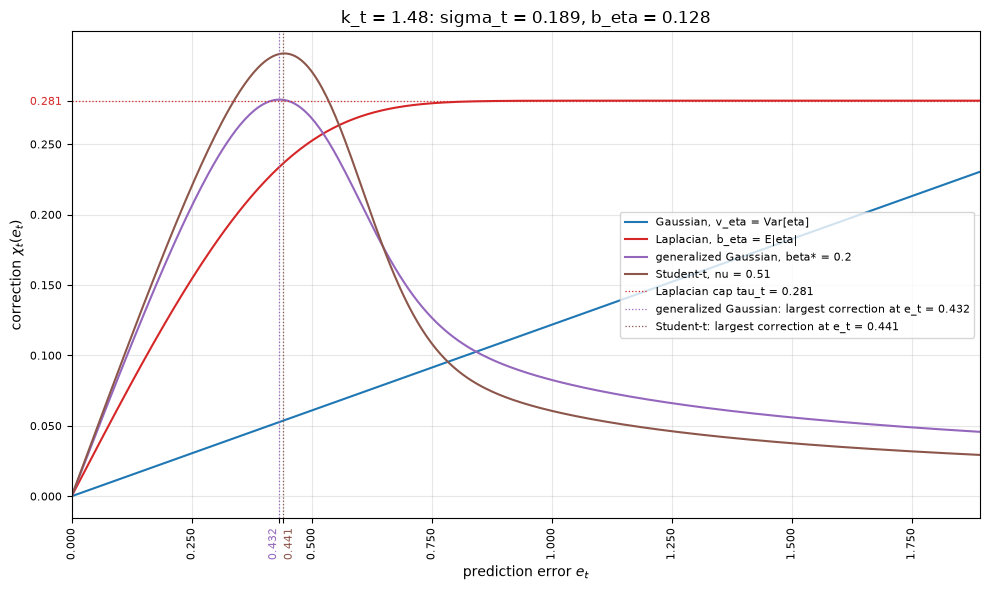

at e_t = 10 sigma_t = 1.893: Gaussian 0.230, Laplacian 0.281, generalized Gaussian 0.046, Student-t 0.029

whole notebook: 0.4 min


In [12]:
sigma_figure = K_MEDIAN_07*b_eta                  # sigma_t at the median k_t of notebook 07
tau_figure = sigma_figure**2/b_eta                 # the Laplacian cap, tau_t of eq. (43)
e_axis = np.linspace(0, 10*sigma_figure, 400)

curves = []                                        # name, colour and chi(e) of each noise model
chi_curve = []
for e in e_axis:
    chi_curve.append(chi_gaussian(e, sigma_figure, var_eta)[0])
curves.append(("Gaussian, v_eta = Var[eta]", "C0", np.array(chi_curve)))
chi_curve = []
for e in e_axis:
    chi_curve.append(chi_laplacian(e, sigma_figure, b_eta)[0])
curves.append(("Laplacian, b_eta = E|eta|", "C3", np.array(chi_curve)))
chi_curve = []
for e in e_axis:
    chi_curve.append(chi_quadrature(e, sigma_figure, "gg", PARAMS_GG)[0])
curves.append((f"generalized Gaussian, beta* = {BETA}", "C4", np.array(chi_curve)))
chi_curve = []
for e in e_axis:
    chi_curve.append(chi_quadrature(e, sigma_figure, "t", PARAMS_T)[0])
curves.append((f"Student-t, nu = {nu_t:.2f}", "C5", np.array(chi_curve)))

fig, ax = plt.subplots(figsize=(10, 6))
levels, colours_y, instants, colours_x = [tau_figure], ["C3"], [], []
for name, colour, chi_curve in curves:
    ax.plot(e_axis, chi_curve, color=colour, linewidth=1.5, label=name)
ax.axhline(tau_figure, color="C3", linestyle=":", linewidth=0.9,
           label=f"Laplacian cap tau_t = {tau_figure:.3f}")
for name, colour, chi_curve in curves[2:]:         # the two that redescend: where they peak
    peak = int(np.argmax(chi_curve))
    ax.axvline(e_axis[peak], color=colour, linestyle=":", linewidth=0.9,
               label=f"{name.split(',')[0]}: largest correction at e_t = {e_axis[peak]:.3f}")
    instants.append(e_axis[peak])
    colours_x.append(colour)
ax.set_xlim(0, e_axis[-1])
ax.set_xlabel("prediction error $e_t$")
ax.set_ylabel("correction $\\chi_t(e_t)$")
ax.set_title(f"k_t = {K_MEDIAN_07:.2f}: sigma_t = {sigma_figure:.3f}, b_eta = {b_eta:.3f}")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
add_ticks(ax, "y", levels, colours_y, 3, 0.02)
add_ticks(ax, "x", instants, colours_x, 3, 0.03*e_axis[-1])
plt.tight_layout()
plt.show()

print(f"at e_t = 10 sigma_t = {e_axis[-1]:.3f}: " + ", ".join(
    f"{name.split(',')[0]} {chi_curve[-1]:.3f}" for name, colour, chi_curve in curves))
print(f"\nwhole notebook: {(time.time() - NOTEBOOK_START)/60:.1f} min")

## Appendix: technical checks

The checks behind section 5, on the same grid.

**Details of sections 3, 4 and 6.**

* $\alpha(\beta)$ at $\beta = 1$ gives $b_\eta$, at $\beta = 2$ gives $\alpha^2/2 = v_\eta$, and at $\beta = \beta^*$ gives back the true scale $\alpha_*$ (printed in section 3).
* The likelihood of the generalized Gaussian with $\beta < 1$ has a cusp at $s = e_t$ with detail at the scale $\alpha_* \approx 8\cdot 10^{-6}$; in $z$ it is the smooth $e^{-z}$.
* The nodes are moved once from $[-1, 1]$ to $[0, 1]$, so a piece $[a, b]$ takes $a + (b - a)\,x_i$ with weight $(b - a)\,w_i$.
* The weights are handled in logs, the largest subtracted before exponentiating.
* In `sKF_quadrature` the guards only stop the run if $\chi_t' > 1$ or anything stops being finite.

**(e) Nodes.** Against 2000 nodes per piece, for the two densities with no closed form. The smallest $N$ with both errors below $10^{-6}$ for both densities must be the `N_NODES` = 100 fixed in section 5.

In [13]:
N_CANDIDATES = [25, 50, 100, 200]
TOLERANCE = 1e-6

params_t_reference = density_params("t", nu_t, scale_t, 2000)   # the GG one is in Table 2


def reference_t(e, sigma, params):
    """The Student-t quadrature, as a reference for worst_error."""
    return chi_quadrature(e, sigma, "t", params)


n_chosen = None                                    # the smallest N that passes
print(f"{'N':>5}{'GG chi/sigma':>15}{'GG chi_slope':>15}{'t chi/sigma':>15}{'t chi_slope':>15}")
for n_nodes in N_CANDIDATES:
    error_gg = worst_error("gg", density_params("gg", BETA, alpha_star, n_nodes),
                           reference_gg, params_gg_reference)
    error_t = worst_error("t", density_params("t", nu_t, scale_t, n_nodes),
                          reference_t, params_t_reference)
    print(f"{n_nodes:>5}{error_gg['chi']:>15.2e}{error_gg['slope']:>15.2e}"
          f"{error_t['chi']:>15.2e}{error_t['slope']:>15.2e}")
    worst = max(error_gg["chi"], error_gg["slope"], error_t["chi"], error_t["slope"])
    if n_chosen is None and worst < TOLERANCE:
        n_chosen = n_nodes

assert n_chosen is not None, f"no N in {N_CANDIDATES} reaches {TOLERANCE}"
assert n_chosen == N_NODES, f"the node study picks {n_chosen}, section 5 fixes N_NODES = {N_NODES}"
print(f"\nthe node study picks {n_chosen} nodes per piece, the N_NODES of section 5")

    N   GG chi/sigma   GG chi_slope    t chi/sigma    t chi_slope


   25       9.29e-06       5.16e-05       3.59e-03       3.01e-03


   50       7.47e-13       3.12e-12       1.07e-05       2.99e-05


  100       9.26e-13       1.78e-12       1.77e-09       6.81e-09


  200       6.18e-13       1.35e-12       1.94e-12       1.74e-12

the node study picks 100 nodes per piece, the N_NODES of section 5


**(c) Slope.** For $\beta^*$ and the Student-t, which have no closed form: $\chi'$ of the quadrature against $(\chi(e+h) - \chi(e-h))/2h$, $h = 10^{-4}\sigma_t$. Eq. (30) says they are the same. This checks the posterior is used consistently, not the change of variable: any error that only reshapes $p_\eta(e_t - s)$ keeps the identity.

**(c2) Change of variable.** For $\beta^*$: the pieces in $z$ against the same integral directly in $s$, with every piece split into sub-pieces that halve towards both ends, 46 times, 20 nodes each. Once on the grid, once at the large $k_t$ of the start of a run.

In [14]:
for label, density, params in [("GG beta*", "gg", PARAMS_GG), ("Student-t", "t", PARAMS_T)]:
    worst = 0.0
    for k_t in K_GRID:
        sigma = k_t*b_eta
        h = 1e-4*sigma
        for e in E_GRID:
            chi_slope = chi_quadrature(e, sigma, density, params)[1]
            chi_plus = chi_quadrature(e + h, sigma, density, params)[0]
            chi_minus = chi_quadrature(e - h, sigma, density, params)[0]
            worst = max(worst, abs(chi_slope - (chi_plus - chi_minus)/(2*h)))
    print(f"(c) {label:<10}: max |chi' - finite difference| = {worst:.2e}")


def graded_edges(s_a, s_b):
    """Edges of sub-pieces of [s_a, s_b] that halve towards both ends, 46 times each way."""
    middle = (s_a + s_b)/2
    edges = [s_a, middle, s_b]
    for level in range(1, 47):
        edges.append(s_a + (middle - s_a)*0.5**level)   # towards s_a
        edges.append(s_b - (s_b - middle)*0.5**level)   # towards s_b
    return np.sort(edges)


def chi_graded_in_s(e, sigma, params):
    """The generalized Gaussian quadrature with no change of variable: same cuts, nodes in s."""
    params_20 = density_params("gg", params["beta"], params["alpha"], 20)   # 20 nodes per sub-piece
    cuts = sorted([-L_WINDOW*sigma, 0.0, e, L_WINDOW*sigma])
    s_all = []
    log_q_all = []
    for piece in range(3):
        edges = graded_edges(cuts[piece], cuts[piece + 1])
        for j in range(len(edges) - 1):
            if edges[j + 1] <= edges[j]:
                continue
            s, log_q = piece_in_s(e, edges[j], edges[j + 1], "gg", params_20)
            s_all.append(s)
            log_q_all.append(log_q - s*s/(2*sigma**2))
    s = np.concatenate(s_all)
    log_q = np.concatenate(log_q_all)
    q = np.exp(log_q - log_q.max())
    mean = (q @ s)/q.sum()
    var = (q @ (s - mean)**2)/q.sum()
    return mean, 1 - var/sigma**2


error_c2 = worst_error("gg", PARAMS_GG, chi_graded_in_s, PARAMS_GG)
print(f"(c2) GG beta*, z against s  : chi/sigma {error_c2['chi']:.2e}, chi' {error_c2['slope']:.2e}")

# The same at the k_t of a transient: v starts at 2, so every run begins near k_t = 90.
worst_chi = 0.0
worst_slope = 0.0
for k_t in [5.0, 10.0, 30.0, 100.0]:
    sigma = k_t*b_eta
    for e in E_GRID:
        chi, chi_slope = chi_quadrature(e, sigma, "gg", PARAMS_GG)
        chi_ref, chi_slope_ref = chi_graded_in_s(e, sigma, PARAMS_GG)
        worst_chi = max(worst_chi, abs(chi - chi_ref)/sigma)
        worst_slope = max(worst_slope, abs(chi_slope - chi_slope_ref))
print(f"     same at k_t = 5 to 100  : chi/sigma {worst_chi:.2e}, chi' {worst_slope:.2e}   "
      f"(the start of a run, v_0 = 2)")

(c) GG beta*  : max |chi' - finite difference| = 3.76e-09
(c) Student-t : max |chi' - finite difference| = 1.57e-07


(c2) GG beta*, z against s  : chi/sigma 9.89e-13, chi' 1.90e-12


     same at k_t = 5 to 100  : chi/sigma 2.01e-14, chi' 4.88e-14   (the start of a run, v_0 = 2)


**(d) Bound.** $\chi' \le 1$ everywhere, from $\mathrm{Var} \ge 0$. Neither the generalized Gaussian with $\beta < 1$ nor the Student-t is log-concave, so $\chi' < 0$ is allowed (Section 3.2): how often, and how low.

In [15]:
print(f"{'density':<12}{'max chi_slope':>15}{'chi_slope < -1e-9':>20}{'min chi_slope':>15}")
for label, density, params in [("Laplacian", "gg", density_params("gg", 1.0, b_eta, N_NODES)),
                               ("GG beta*", "gg", PARAMS_GG),
                               ("Student-t", "t", PARAMS_T)]:
    slopes = []
    for k_t in K_GRID:
        for e in E_GRID:
            slopes.append(chi_quadrature(e, k_t*b_eta, density, params)[1])
    slopes = np.array(slopes)
    assert slopes.max() <= 1 + 1e-9, f"{label}: chi' = {slopes.max()} > 1"
    print(f"{label:<12}{slopes.max():>15.6f}{np.mean(slopes < -1e-9):>19.1%}{slopes.min():>15.4f}")
print("   -1e-9 leaves out roundoff around 0, where the Laplacian slope goes for large errors")
print("   the fraction is of the grid, not of the steps of a run: notebook 09 counts those")

density       max chi_slope   chi_slope < -1e-9  min chi_slope
Laplacian          0.654564               0.0%        -0.0000
GG beta*           0.875265              35.6%        -0.6893
Student-t          0.918372              35.1%        -0.9766
   -1e-9 leaves out roundoff around 0, where the Laplacian slope goes for large errors
   the fraction is of the grid, not of the steps of a run: notebook 09 counts those
